# Transfer learning and fine-tuning

En este tutorial, como ejemplo, se podrá clasificar imágenes de gatos y perros utilizando el aprendizaje de transferencia de una red previamente entrenada. Este se basa en tutoriales oficiales de TensorFlow (https://www.tensorflow.org/)

Un modelo preentrenado es una red guardada que se entrenó previamente en un gran conjunto de datos, generalmente en una tarea de clasificación de imágenes a gran escala. Puede usar el modelo preentrenado tal como está o usar el aprendizaje de transferencia para personalizar este modelo para una tarea determinada.

La intuición detrás del aprendizaje de transferencia para la clasificación de imágenes es que si un modelo se entrena en un conjunto de datos lo suficientemente grande y general, este modelo servirá efectivamente como un modelo genérico del mundo visual. A continuación, puede aprovechar estos mapas de características aprendidos sin tener que empezar de cero entrenando un modelo grande en un conjunto de datos grande.

En este cuaderno, probará dos formas de personalizar un modelo previamente entrenado:

1. **Extracción de características**: use las representaciones aprendidas por una red anterior para extraer características significativas de nuevas muestras. Simplemente agregue un nuevo clasificador, que se entrenará desde cero, encima del modelo previamente entrenado para que pueda reutilizar los mapas de características aprendidos previamente para el conjunto de datos.

  No necesita (re)entrenar todo el modelo. La red convolucional base ya contiene características que son genéricamente útiles para clasificar imágenes. Sin embargo, la parte de clasificación final del modelo preentrenado es específica de la tarea de clasificación original y, posteriormente, específica del conjunto de clases en las que se entrenó el modelo.

2. **Ajuste fino**: descongele algunas de las capas superiores de una base de modelo congelada y entrene conjuntamente las capas clasificadoras recién agregadas y las últimas capas del modelo base. Esto nos permite "afinar" las representaciones de características de orden superior en el modelo base para que sean más relevantes para la tarea específica.

Seguirá el flujo de trabajo general de aprendizaje automático.

1. Examinar y comprender los datos
1. Cree una tubería de entrada (*pipeline*), en este caso usando Keras ImageDataGenerator
1. Componer el modelo
    * Carga en el modelo base preentrenado (y pesos preentrenados)
    * Apila las capas de clasificación en la parte superior
1. Entrena al modelo
1. Evaluar modelo


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

## Preprocesamiento de datos

### Descarga de datos

En este tutorial, utilizará un conjunto de datos que contiene varios miles de imágenes de gatos y perros. Descargue y extraiga un archivo zip que contenga las imágenes, luego cree un `tf.data.Dataset` para entrenamiento y validación usando la utilidad `tf.keras.utils.image_dataset_from_directory`. Puede obtener más información sobre cómo cargar imágenes en este [tutorial] (https://www.tensorflow.org/tutorials/load_data/images).

In [2]:
_URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
path_to_zip = tf.keras.utils.get_file('cats_and_dogs.zip', origin=_URL, extract=True)
PATH = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')

BATCH_SIZE = 32
IMG_SIZE = (160, 160)

train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                            shuffle=True,
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE)

68606236/68606236 [==============================] - 0s 0us/step
Found 2000 files belonging to 2 classes.


In [3]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(validation_dir,
                                                                 shuffle=True,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE)

Found 1000 files belonging to 2 classes.


Muestre las primeras nueve imágenes y etiquetas del conjunto de entrenamiento:

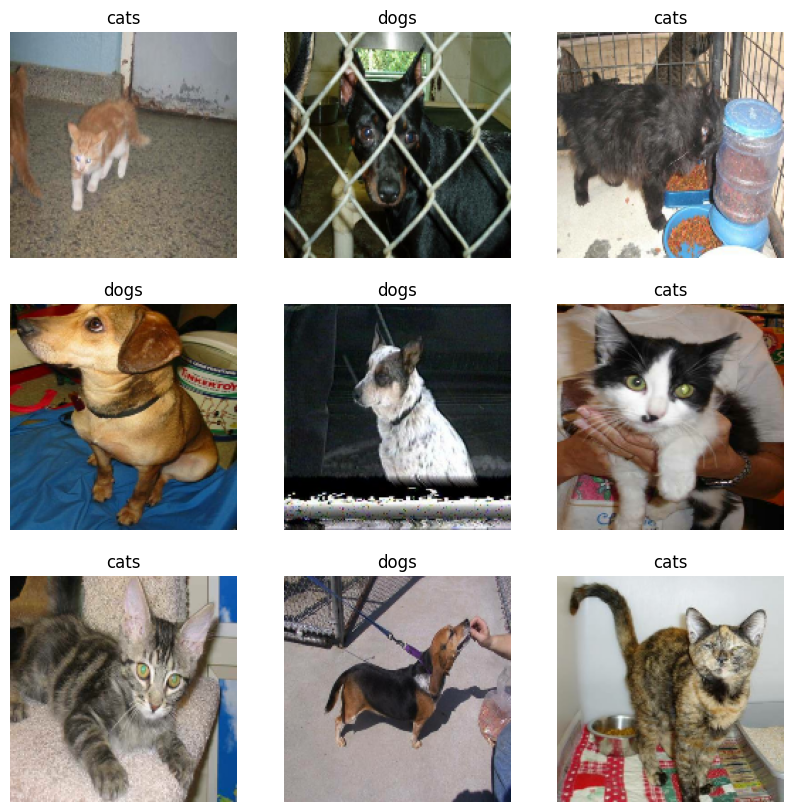

In [4]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

Como el conjunto de datos original no contiene un conjunto de prueba, creará uno. Para hacerlo, determine cuántos lotes de datos están disponibles en el conjunto de validación usando `tf.data.experimental.cardinality`, luego mueva el 20% de ellos a un conjunto de prueba.

In [5]:
val_batches = tf.data.experimental.cardinality(validation_dataset)
test_dataset = validation_dataset.take(val_batches // 5)
validation_dataset = validation_dataset.skip(val_batches // 5)

In [7]:
print('Número de lotes de validación: %d' % tf.data.experimental.cardinality(validation_dataset))
print('Número de lotes de testeo: %d' % tf.data.experimental.cardinality(test_dataset))

Número de lotes de validación: 26
Número de lotes de testeo: 6


### Configurar el conjunto de datos para mejor rendimiento

UUtilice *buffered prefetching* para cargar imágenes desde el disco sin que la E/S se convierta en un bloqueo. Para obtener más información sobre este método, consulte la guía [rendimiento de datos](https://www.tensorflow.org/guide/data_performance).

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

### Utilice data augmentation

Cuando no tiene un conjunto de datos de imágenes grande, es una buena práctica introducir artificialmente diversidad de muestras mediante la aplicación de transformaciones aleatorias pero realistas a las imágenes de entrenamiento, como la rotación y el volteo horizontal. Esto ayuda a exponer el modelo a diferentes aspectos de los datos de entrenamiento y reduce el overfitting (https://www.tensorflow.org/tutorials/keras/overfit_and_underfit). Puede obtener más información sobre el aumento de datos en este [tutorial](https://www.tensorflow.org/tutorials/images/data_augmentation).

In [9]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

Nota: Estas capas están activas solo durante el entrenamiento, cuando llamas a `Model.fit`. Están inactivos cuando el modelo se usa en modo de inferencia en `Model.evaluate` o `Model.fit`.

Apliquemos repetidamente estas capas a la misma imagen y veamos el resultado.

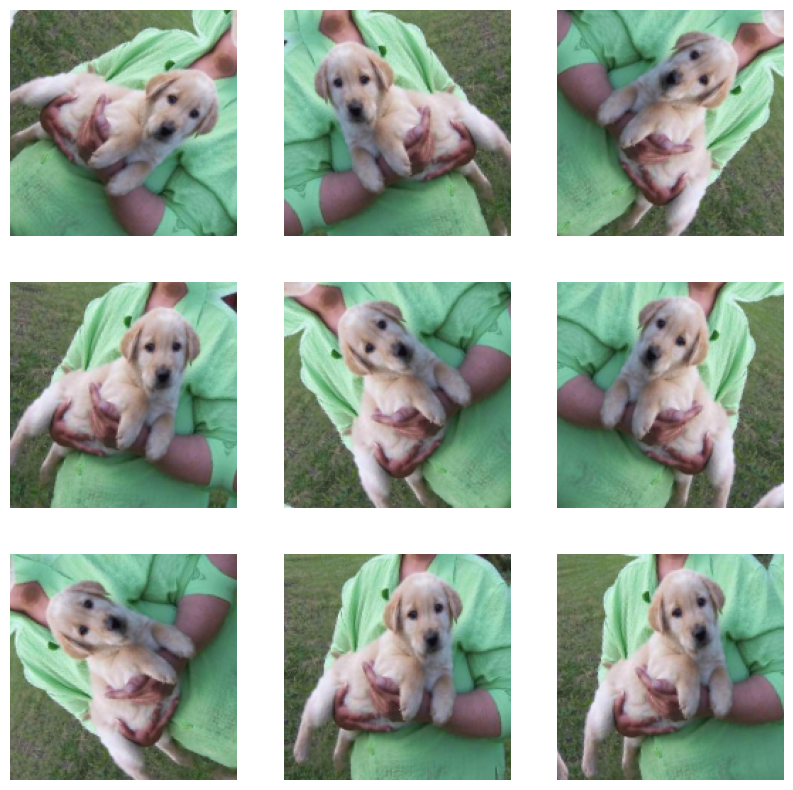

In [10]:
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

### Rescalar píxeles

En un momento, descargará `tf.keras.applications.MobileNetV2` para usarlo como su modelo base. Este modelo espera valores de píxeles en `[-1, 1]`, pero en este punto, los valores de píxeles en sus imágenes están en `[0, 255]`. Para volver a escalarlos, utilice el método de preprocesamiento incluido con el modelo.

In [11]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

Nota: Alternativamente, puede cambiar la escala de los valores de píxeles de `[0, 255]` a `[-1, 1]` utilizando `tf.keras.layers.Rescaling`.

In [12]:
rescale = tf.keras.layers.Rescaling(1./127.5, offset=-1)

Nota: si usa otras `tf.keras.applications`, asegúrese de consultar el documento de la API para determinar si esperan píxeles en `[-1, 1]` o `[0, 1]`, o use el `preprocess_input' incluido ` función.

## Crea el modelo base a partir de las redes de convección preentrenadas
Creará el modelo base a partir del modelo **MobileNet V2** desarrollado en Google. Esto se entrena previamente en el conjunto de datos de ImageNet, un gran conjunto de datos que consta de 1,4 millones de imágenes y 1000 clases. ImageNet es un conjunto de datos de entrenamiento de investigación con una amplia variedad de categorías como "jackfruit" y "syringe". Esta base de conocimientos nos ayudará a clasificar perros y gatos a partir de nuestro conjunto de datos específico.

Primero, debe elegir qué capa de MobileNet V2 utilizará para la extracción de características. La última capa de clasificación (en "arriba", ya que la mayoría de los diagramas de modelos de aprendizaje automático van de abajo hacia arriba) no es muy útil. En su lugar, seguirá la práctica común de depender de la última capa antes de la operación de aplanado. Esta capa se denomina "capa de cuello de botella". Las características de la capa de cuello de botella conservan más generalidad en comparación con la capa final/superior.

Primero, cree una instancia de un modelo MobileNet V2 precargado con pesos entrenados en ImageNet. Al especificar el argumento **include_top=False**, carga una red que no incluye las capas de clasificación en la parte superior, lo que es ideal para la extracción de características.

In [13]:
# Cree el modelo base a partir del modelo previamente entrenado MobileNet V2
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

9406464/9406464 [==============================] - 0s 0us/step


Este extractor de funciones convierte cada imagen `160x160x3` en un bloque de funciones `5x5x1280`. Veamos qué le hace a un lote de imágenes de ejemplo:

In [14]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 5, 5, 1280)


## Extracción de características
En este paso, congelará la base convolucional creada en el paso anterior y la utilizará como extractor de características. Además, agrega un clasificador encima y entrena el clasificador de nivel superior.

### Congelar la base convolucional

Es importante congelar la base convolucional antes de compilar y entrenar el modelo. Congelar (estableciendo layer.trainable = False) evita que los pesos en una capa determinada se actualicen durante el entrenamiento. MobileNet V2 tiene muchas capas, por lo que establecer el indicador `entrenable` de todo el modelo en False las congelará todas.

In [15]:
base_model.trainable = False

### Nota importante sobre las capas de BatchNormalization

Muchos modelos contienen capas `tf.keras.layers.BatchNormalization`. Esta capa es un caso especial y se deben tomar precauciones en el contexto del ajuste fino, como se muestra más adelante en este tutorial.

Cuando configura `layer.trainable = False`, la capa `BatchNormalization` se ejecutará en modo de inferencia y no actualizará sus estadísticas de media y varianza.

Cuando descongela un modelo que contiene capas de BatchNormalization para realizar un ajuste fino, debe mantener las capas de BatchNormalization en modo de inferencia pasando `training = False` al llamar al modelo base. De lo contrario, las actualizaciones aplicadas a los pesos no entrenables destruirán lo aprendido por el modelo.

In [16]:
# Veamos un resumen de red
base_model.summary()

Model: "mobilenetv2_1.00_160"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 160, 160, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 80, 80, 32)   864         ['input_1[0][0]']                
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 80, 80, 32)   128         ['Conv1[0][0]']                  
                                                                                                  
 Conv1_relu (ReLU)              (None, 80, 80, 32)   0           ['bn_Conv1[0][

### Agregue una cabeza de clasificación.

Para generar predicciones a partir del bloque de características, promedie las ubicaciones espaciales espaciales "5x5", utilizando una capa "tf.keras.layers.GlobalAveragePooling2D" para convertir las características en un solo vector de 1280 elementos por imagen.

In [17]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


Aplique una capa `tf.keras.layers.Dense` para convertir estas características en una sola predicción por imagen. No necesita una función de activación aquí porque esta predicción se tratará como un `logit` o un valor de predicción sin procesar. Los números positivos predicen la clase 1, los números negativos predicen la clase 0.

In [18]:
prediction_layer = tf.keras.layers.Dense(1)
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 1)


Cree un modelo encadenando las capas de aumento de datos, reescalado, `base_model` y extractor de características utilizando la [API funcional de Keras] (https://www.tensorflow.org/guide/keras/funcional). Como se mencionó anteriormente, use `training=False` ya que nuestro modelo contiene una capa `BatchNormalization`.

In [19]:
inputs = tf.keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

### Compile el modelo

Compile el modelo antes de entrenarlo. Dado que hay dos clases, use la pérdida `tf.keras.losses.BinaryCrossentropy` con `from_logits=True` ya que el modelo proporciona una salida lineal.

In [20]:
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [21]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 160, 160, 3)       0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 160, 160, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 160, 160, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_160 (Funct  (None, 5, 5, 1280)       2257984   
 ional)                                                          
                                                             

Los 2,5 millones de parámetros en MobileNet están congelados, pero hay 1,2 mil parámetros _entrenables_ en la capa densa. Estos se dividen entre dos objetos `tf.Variable`, los pesos y los sesgos.

In [22]:
len(model.trainable_variables)

2

### Entrenar al modelo

Después de entrenar durante 10 épocas, debería ver una precisión de ~94 % en el conjunto de validación.


In [23]:
initial_epochs = 10

loss0, accuracy0 = model.evaluate(validation_dataset)

26/26 [==============================] - 21s 664ms/step - loss: 1.0963 - accuracy: 0.2908


In [24]:
print("Loss inicial: {:.2f}".format(loss0))
print("Accuracy inicial: {:.2f}".format(accuracy0))

Loss inicial: 1.10
Accuracy inicial: 0.29


In [25]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/10
63/63 [==============================] - 82s 1s/step - loss: 0.8933 - accuracy: 0.4585 - val_loss: 0.7505 - val_accuracy: 0.5161
Epoch 2/10
63/63 [==============================] - 67s 1s/step - loss: 0.6701 - accuracy: 0.6090 - val_loss: 0.5289 - val_accuracy: 0.7129
Epoch 3/10
63/63 [==============================] - 77s 1s/step - loss: 0.5044 - accuracy: 0.7405 - val_loss: 0.3966 - val_accuracy: 0.8205
Epoch 4/10
63/63 [==============================] - 81s 1s/step - loss: 0.4180 - accuracy: 0.8015 - val_loss: 0.3161 - val_accuracy: 0.8614
Epoch 5/10
63/63 [==============================] - 81s 1s/step - loss: 0.3525 - accuracy: 0.8350 - val_loss: 0.2606 - val_accuracy: 0.8998
Epoch 6/10
63/63 [==============================] - 63s 1s/step - loss: 0.3073 - accuracy: 0.8650 - val_loss: 0.2186 - val_accuracy: 0.9196
Epoch 7/10
63/63 [==============================] - 66s 1s/step - loss: 0.2823 - accuracy: 0.8775 - val_loss: 0.1949 - val_accuracy: 0.9332
Epoch 8/10
63/63 [==

### Curvas de aprendizaje

Echemos un vistazo a las curvas de aprendizaje de la precisión/pérdida de capacitación y validación cuando se usa el modelo base de MobileNetV2 como un extractor de características fijas.

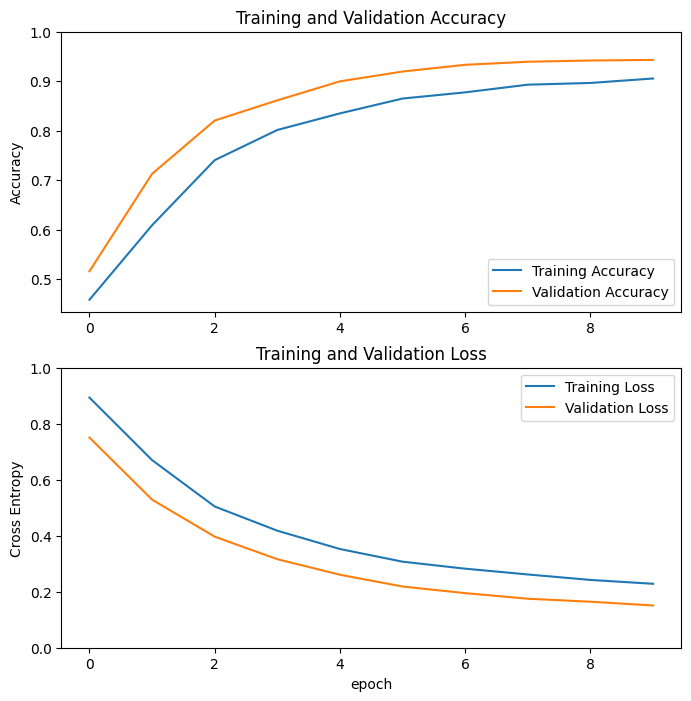

In [32]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

Nota: si se pregunta por qué las métricas de validación son claramente mejores que las métricas de entrenamiento, el factor principal es que capas como `tf.keras.layers.BatchNormalization` y `tf.keras.layers.Dropout` afectan la precisión durante el entrenamiento. Se desactivan al calcular la pérdida de validación.

En menor medida, también se debe a que las métricas de entrenamiento informan el promedio de una época, mientras que las métricas de validación se evalúan después de la época, por lo que las métricas de validación ven un modelo que se ha entrenado un poco más.

## Fine-tuning
En el experimento de extracción de características, solo estaba entrenando algunas capas sobre un modelo base de MobileNetV2. Los pesos de la red preentrenada **no** se actualizaron durante el entrenamiento.

Una forma de aumentar aún más el rendimiento es entrenar (o "afinar") los pesos de las capas superiores del modelo preentrenado junto con el entrenamiento del clasificador que agregó. El proceso de entrenamiento obligará a ajustar los pesos de los mapas de características genéricas a las características asociadas específicamente con el conjunto de datos.

Nota: Esto solo debe intentarse después de haber entrenado el clasificador de nivel superior con el modelo preentrenado establecido en no entrenable. Si agrega un clasificador inicializado aleatoriamente encima de un modelo previamente entrenado e intenta entrenar todas las capas juntas, la magnitud de las actualizaciones de gradiente será demasiado grande (debido a los pesos aleatorios del clasificador) y su modelo previamente entrenado olvidar lo que ha aprendido.

Además, debe intentar ajustar una pequeña cantidad de capas superiores en lugar de todo el modelo de MobileNet. En la mayoría de las redes convolucionales, cuanto más arriba está una capa, más especializada es. Las primeras capas aprenden características muy simples y genéricas que se generalizan a casi todos los tipos de imágenes. A medida que avanza, las funciones son cada vez más específicas para el conjunto de datos en el que se entrenó el modelo. El objetivo del ajuste fino es adaptar estas características especializadas para que funcionen con el nuevo conjunto de datos, en lugar de sobrescribir el aprendizaje genérico.

### Descongele las capas superiores del modelo.


Todo lo que necesita hacer es descongelar el `base_model` y configurar las capas inferiores para que no se puedan entrenar. Luego, debe volver a compilar el modelo (necesario para que estos cambios surtan efecto) y reanudar el entrenamiento.

In [33]:
base_model.trainable = True

In [34]:
# Echemos un vistazo para ver cuántas capas hay en el modelo base
print("Número de capas en el modelo base: ", len(base_model.layers))

# Ajuste fino desde esta capa en adelante
fine_tune_at = 100

# Congelar todas las capas antes de la capa `fine_tune_at`
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Número de capas en el modelo base:  154


### Compile el modelo

Como está entrenando un modelo mucho más grande y quiere readaptar los pesos previamente entrenados, es importante usar una tasa de aprendizaje más baja en esta etapa. De lo contrario, su modelo podría sobreajustarse muy rápidamente.

In [35]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate/10),
              metrics=['accuracy'])

In [36]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 160, 160, 3)       0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 160, 160, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 160, 160, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_160 (Funct  (None, 5, 5, 1280)       2257984   
 ional)                                                          
                                                             

In [37]:
len(model.trainable_variables)

56

### Continue entrenando al modelo

Si se entrenó antes para la convergencia, este paso mejorará su precisión en algunos puntos porcentuales.

In [38]:
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1],
                         validation_data=validation_dataset)

Epoch 10/20
63/63 [==============================] - 107s 2s/step - loss: 0.1416 - accuracy: 0.9345 - val_loss: 0.0685 - val_accuracy: 0.9703
Epoch 11/20
63/63 [==============================] - 94s 1s/step - loss: 0.1201 - accuracy: 0.9500 - val_loss: 0.0537 - val_accuracy: 0.9889
Epoch 12/20
63/63 [==============================] - 88s 1s/step - loss: 0.1024 - accuracy: 0.9595 - val_loss: 0.0601 - val_accuracy: 0.9839
Epoch 13/20
63/63 [==============================] - 99s 2s/step - loss: 0.0982 - accuracy: 0.9615 - val_loss: 0.0498 - val_accuracy: 0.9802
Epoch 14/20
63/63 [==============================] - 98s 2s/step - loss: 0.0896 - accuracy: 0.9660 - val_loss: 0.0425 - val_accuracy: 0.9802
Epoch 15/20
63/63 [==============================] - 97s 2s/step - loss: 0.0817 - accuracy: 0.9695 - val_loss: 0.0444 - val_accuracy: 0.9790
Epoch 16/20
63/63 [==============================] - 96s 2s/step - loss: 0.0751 - accuracy: 0.9675 - val_loss: 0.0358 - val_accuracy: 0.9889
Epoch 17/20


Echemos un vistazo a las curvas de aprendizaje de la precisión/pérdida de entrenamiento y validación cuando se ajustan las últimas capas del modelo base de MobileNetV2 y se entrena el clasificador encima. La pérdida de validación es mucho mayor que la pérdida de entrenamiento, por lo que es posible que se sobreajuste.

También es posible que se sobreajuste, ya que el nuevo conjunto de entrenamiento es relativamente pequeño y similar a los conjuntos de datos originales de MobileNetV2.

Después de un ajuste fino, el modelo alcanza casi el 98 % de precisión en el conjunto de validación.

In [39]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

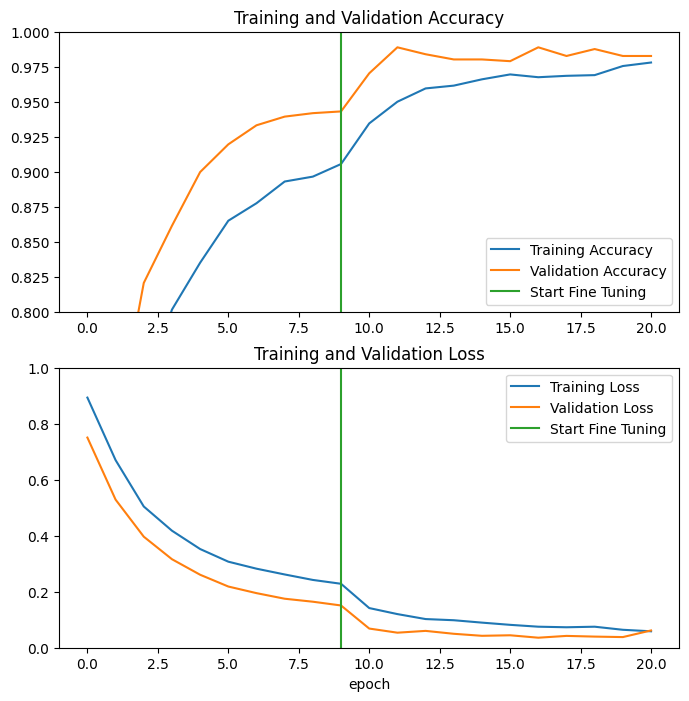

In [40]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

### Evaluación y predicción

Finalmente, puede verificar el rendimiento del modelo en nuevos datos utilizando un conjunto de prueba.

In [41]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

6/6 [==============================] - 4s 598ms/step - loss: 0.0593 - accuracy: 0.9844
Test accuracy : 0.984375


Y ahora está todo listo para usar este modelo para predecir si su mascota es un gato o un perro.

Predictions:
 [1 0 1 1 1 0 1 1 0 0 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0]
Labels:
 [1 0 1 1 1 0 0 1 0 0 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0]


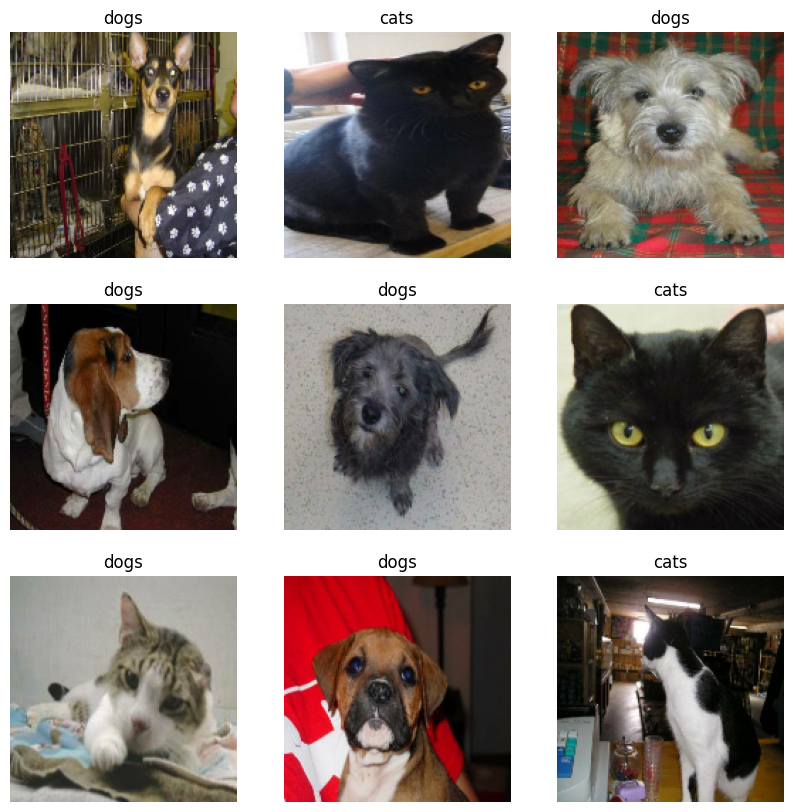

In [42]:
# Recuperar un lote de imágenes del conjunto de prueba
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch).flatten()

# Aplicar un sigmoide ya que nuestro modelo devuelve logits
predictions = tf.nn.sigmoid(predictions)
predictions = tf.where(predictions < 0.5, 0, 1)

print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)

plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]])
  plt.axis("off")

## Resumen

* **Uso de un modelo previamente entrenado para la extracción de funciones**: cuando se trabaja con un conjunto de datos pequeño, es una práctica común aprovechar las funciones aprendidas por un modelo entrenado en un conjunto de datos más grande en el mismo dominio. Esto se hace instanciando el modelo previamente entrenado y agregando un clasificador completamente conectado en la parte superior. El modelo preentrenado se "congela" y solo los pesos del clasificador se actualizan durante el entrenamiento.
En este caso, la base convolucional extrajo todas las características asociadas con cada imagen y solo entrenó un clasificador que determina la clase de imagen dado ese conjunto de características extraídas.

* **Ajuste fino de un modelo preentrenado**: para mejorar aún más el rendimiento, es posible que desee reutilizar las capas de nivel superior de los modelos preentrenados para el nuevo conjunto de datos a través del ajuste fino.
En este caso, ajustó sus ponderaciones de modo que su modelo aprendiera características de alto nivel específicas del conjunto de datos. Esta técnica generalmente se recomienda cuando el conjunto de datos de entrenamiento es grande y muy similar al conjunto de datos original en el que se entrenó el modelo previamente entrenado.

